KNN Classification Results:
Training Dataset:First 50 points labeled based on the rule (x<=0.5->Class1, x>0.5->Class2)
Testing dataset:Remaining 50 points to be classified 

Results for k = 1:
Point x51 (value: 0.5972) is classified asClass2
Point x52 (value: 0.5916) is classified asClass2
Point x53 (value: 0.1583) is classified asClass1
Point x54 (value: 0.3178) is classified asClass1
Point x55 (value: 0.6818) is classified asClass2
Point x56 (value: 0.5493) is classified asClass2
Point x57 (value: 0.1227) is classified asClass1
Point x58 (value: 0.3597) is classified asClass1
Point x59 (value: 0.0928) is classified asClass1
Point x60 (value: 0.7618) is classified asClass2
Point x61 (value: 0.1112) is classified asClass1
Point x62 (value: 0.3439) is classified asClass1
Point x63 (value: 0.8185) is classified asClass2
Point x64 (value: 0.2432) is classified asClass1
Point x65 (value: 0.6569) is classified asClass2
Point x66 (value: 0.3978) is classified asClass1
Point x67 (value: 0.679

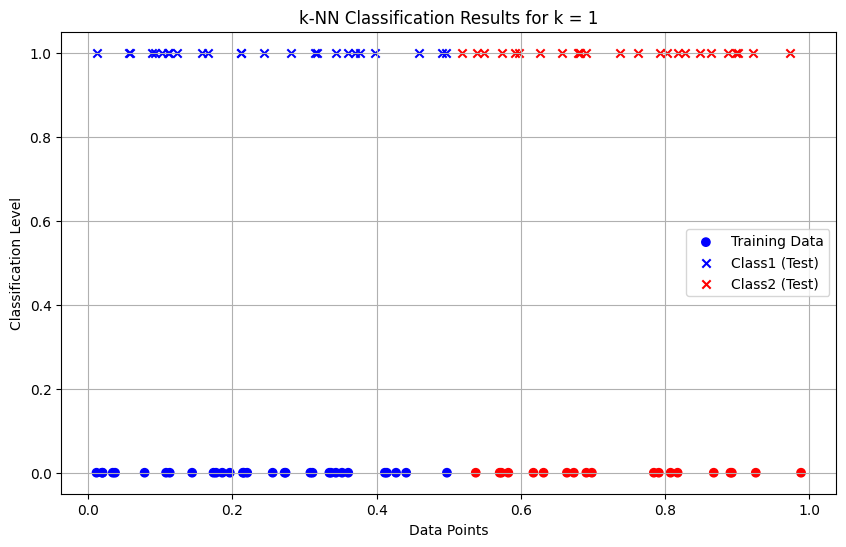

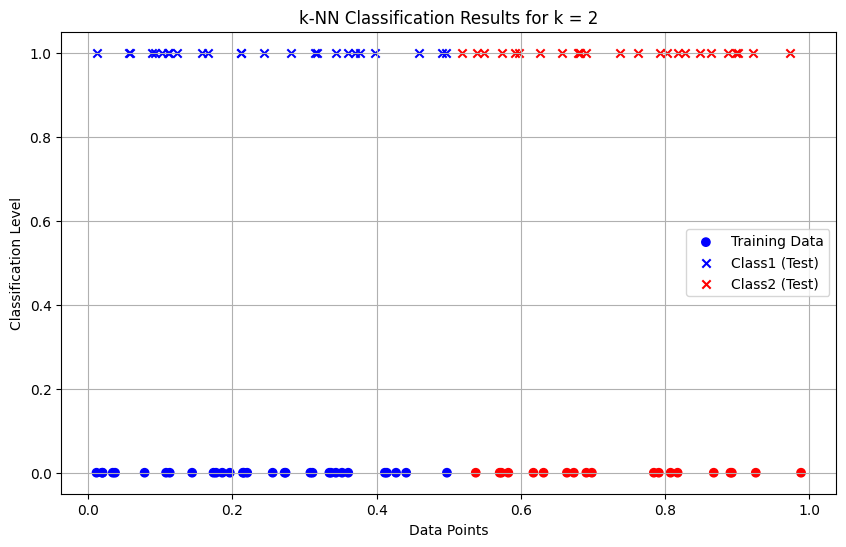

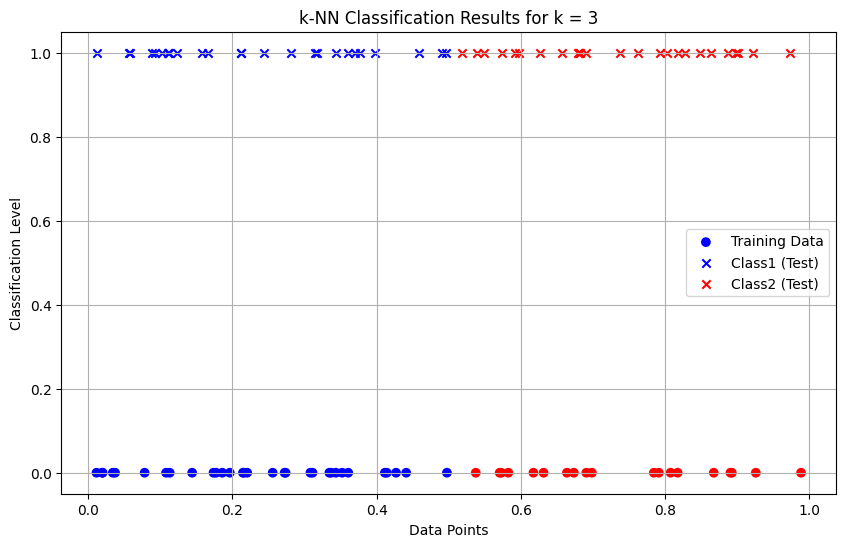

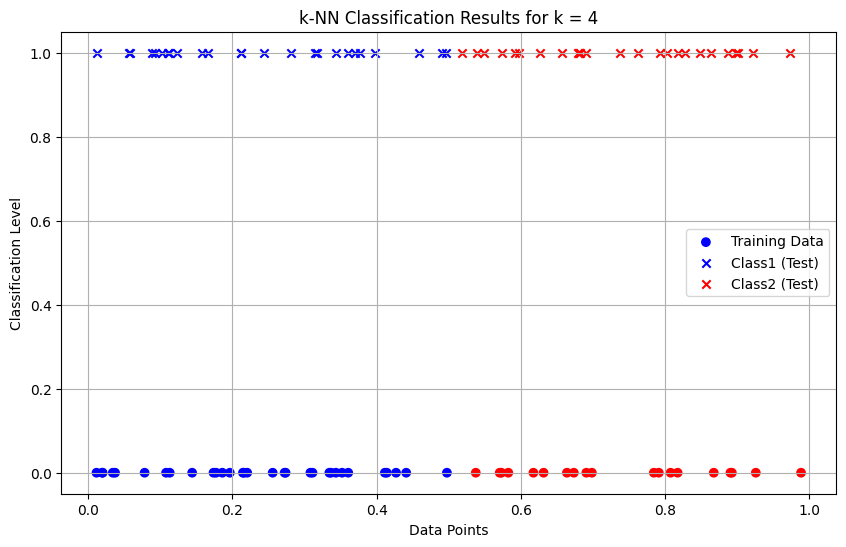

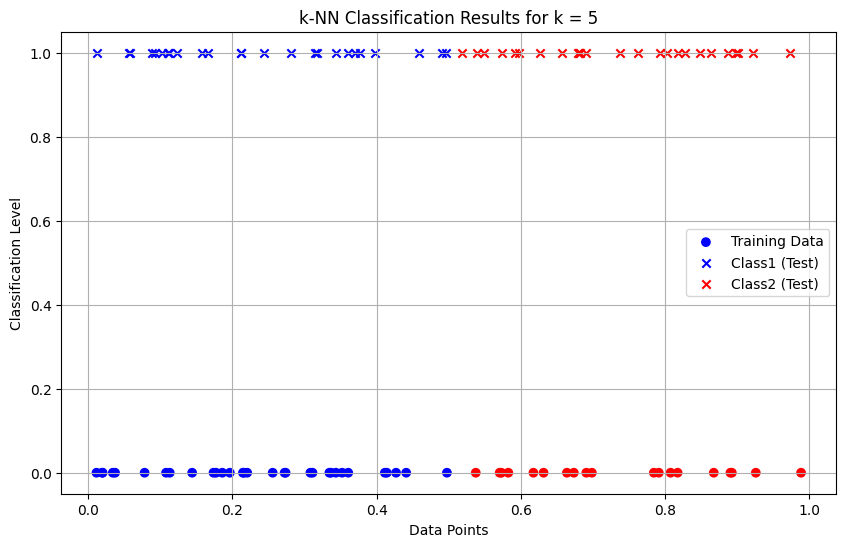

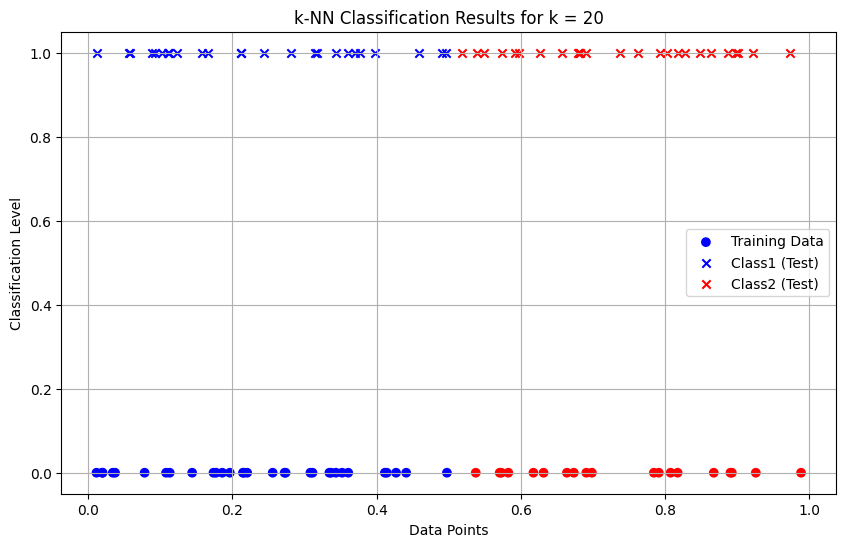

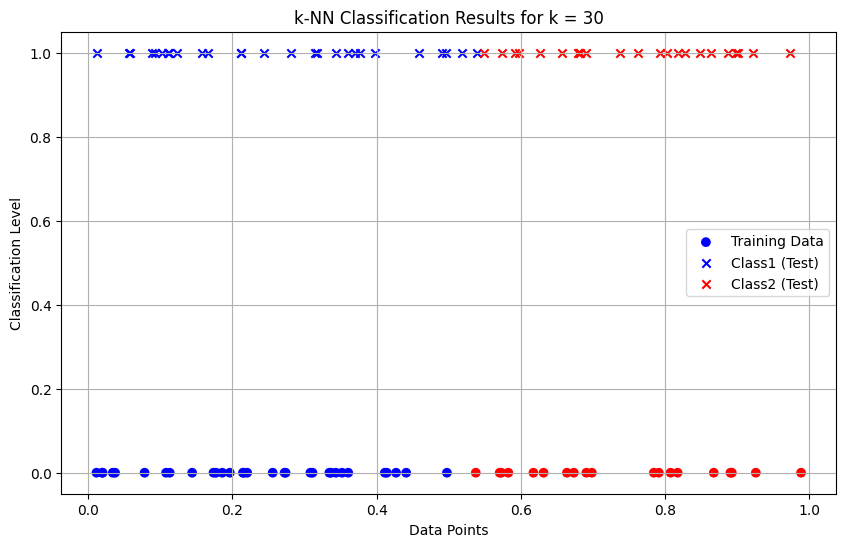

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

data = np.random.rand(100)

labels=["Class1" if x < 0.5 else "Class2" for x in data[:50]]

def euclidean_distance(x1, x2):
    return abs(x1-x2)

def knn_classify(train_data, train_labels, test_point, k):
    distances = [
        (euclidean_distance(test_point, train_data[i]), train_labels[i])
        for i in range(len(train_data))
    ]
    distances.sort(key=lambda x: x[0])
    k_neighbors = distances[:k]
    k_nearest_labels = [label for _, label in k_neighbors]

    return Counter(k_nearest_labels).most_common(1)[0][0]

train_data = data[:50]
train_labels = labels

test_data = data[50:]

k_values = [1,2, 3,4, 5,20,30]

print("KNN Classification Results:")

print("Training Dataset:First 50 points labeled based on the rule (x<=0.5->Class1, x>0.5->Class2)")
print("Testing dataset:Remaining 50 points to be classified \n")

results = {}
for k in k_values:
    print(f"Results for k = {k}:")
    classified_labels = [
        knn_classify(train_data, train_labels, test_point, k)
        for test_point in test_data
    ]
    results[k] = classified_labels

    for i, label in enumerate(classified_labels, start=51):
        print(f"Point x{i} (value: {test_data[i - 51]:.4f}) is classified as{label}")
    print("\n")

print("Classification complete.\n")

for k in k_values:
    classified_labels = results[k]

    class1_points = [
        test_data[i] 
        for i in range(len(test_data)) 
        if classified_labels[i] == "Class1"
    ]
    
    class2_points = [
        test_data[i] 
        for i in range(len(test_data)) 
        if classified_labels[i] == "Class2"
    ]

    plt.figure(figsize=(10, 6))

    plt.scatter(
        train_data,
        [0] * len(train_data),
        c=["blue" if label == "Class1" else "red" for label in train_labels],
        label="Training Data",
        marker="o"
    )

    plt.scatter(
        class1_points,
        [1] * len(class1_points),
        c="blue",
        label="Class1 (Test)",
        marker="x"
    )

    plt.scatter(
        class2_points,
        [1] * len(class2_points),
        c="red",
        label="Class2 (Test)",
        marker="x"
    )

    plt.title(f"k-NN Classification Results for k = {k}")
    plt.xlabel("Data Points")
    plt.ylabel("Classification Level")
    plt.legend()
    plt.grid(True)

    plt.show()